# Анализ интернет-магазина Olist (бразильский e-commerce)

## 1. Бизнес-контекст
Olist — крупная бразильская платформа, объединяющая продавцов и покупателей. 
Компания предоставляет логистику, платежи и поддержку.

**Ключевые стейкхолдеры:** Product Manager, Marketing Manager, Logistics Manager.

## 2. Цель анализа
Выявить узкие места в операционной деятельности и покупательском поведении 
для повышения пожизненной ценности клиента (LTV) на 15% за 6 месяцев.

## 3. Гипотезы
1. **Долгая доставка** — главная причина низких оценок и отсутствия повторных покупок.
2. **80% выручки приносят 20% категорий** (принцип Парето). Остальные категории нерентабельны.
3. **Большинство клиентов совершают только 1 покупку** — слабая программа лояльности.
4. **Сезонность:** Пик продаж приходится на ноябрь (Black Friday) и май (Mother's Day в Бразилии).

## 4. Данные
Использованы 9 датасетов от Olist:
- `Order`— заказы (информация о заказах: статус, дата оформления)  
- `Customers` — данные о покупателях  
- `Sellers` — данные о продавцах 
- `Order items` — позиции заказа  
- `Products` — описание товаров  
- `Payments` — платежи (информация об оплате заказа: способ оплаты, статус, дата)  
- `Reviews` — отзывы покупателей  
- `Geolocation` — геолокация  
- `Product category translations` — переводы категорий товаров

## 5. Используемые метрики
- **Retention** — удержание клиентов по когортам
- **LTV (Lifetime Value)** — средняя выручка на клиента
- **Repeat Rate** — доля клиентов с >1 заказа
- **AOV (Average Order Value)** — средний чек
- **Recency** — давность последнего заказа
- **NPS proxy** — распределение оценок в отзывах

## 6. Структура анализа
1. Предобработка данных
2. Когортный анализ удержания
3. RFM-сегментация клиентов
4. Анализ категорий (ABC)
5. Анализ времени доставки и отзывов
6. Воронка продаж
7. Выводы и рекомендации

# 1. Загрузка данных

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('default')

path = "./data/olist/"

orders = pd.read_csv(path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
geolocation = pd.read_csv(path + 'olist_geolocation_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')
category_translation = pd.read_csv(path + 'product_category_name_translation.csv')

# 2. Разведочный анализ данных

На этом шаге мы начинаем **первоначальное изучение** каждого набора данных, используя:

- `.head()`, `.info()` и `.describe()` для быстрого просмотра
- Проверка:
  - Типы данных
  - Форма каждого набора данных
  - Пропущенные значения
  - Значения исходных столбцов
- Идентификация:
  - Категориальные и числовые характеристики
  - Взаимосвязи между наборами данных
- Документирование:
  - Ранние наблюдения
  - Любые предупреждения или несоответствия

## Цель анализа

- изучить поведение пользователей  
- оценить уровень retention   
- предложить продуктовые улучшения  

---

На первом этапе проведем общий анализ данных, чтобы понять их структуру и качество.

## Orders Dataset

In [3]:
display(orders.head())
display(orders.info())
display(orders['order_status'].value_counts())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


None

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## Customers Dataset

In [4]:
display(customers.head())
display(customers.info())

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


None

## Sellers Dataset

In [5]:
display(sellers.head())
display(sellers.info())
display(sellers["seller_state"].value_counts())

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


None

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

## Order_items Dataset

In [6]:
display(order_items.head())
display(order_items.info())
display(order_items.nunique())

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


None

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

## Product Dataset

In [7]:
display(products.head())
display(products.info())
display(products.describe())
products.isnull().sum()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


None

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

## Payments Dataset

In [8]:
display(payments.head())
display(payments.nunique())
display(payments.info())
display(payments['payment_value'].describe())

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


None

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

## Reviews Dataset

In [9]:
display(reviews.head())
display(reviews.info())
display(reviews.describe())

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


None

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


## Geolocation Dataset

In [10]:
display(geolocation.head())

geolocation = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()
display(geolocation.info())
display(geolocation['geolocation_state'].unique())

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


<class 'pandas.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
 3   geolocation_city             19015 non-null  str    
 4   geolocation_state            19015 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 742.9 KB


None

<StringArray>
['SP', 'RJ', 'ES', 'MG', 'BA', 'SE', 'PE', 'RN', 'AL', 'PB', 'CE', 'PI', 'MA',
 'PA', 'AP', 'AM', 'RR', 'AC', 'DF', 'GO', 'RO', 'TO', 'MT', 'MS', 'PR', 'SC',
 'RS']
Length: 27, dtype: str

## Translation

In [11]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


# 3. Предобработка и исследование данных

## 3.1 Проверка пропусков в ключевых таблицах

In [12]:
def missing_values_table(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
    missing_df = missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)
    if len(missing_df) == 0:
        print(f"\n* {name}: нет пропусков")
    else:
        print(f"\n! {name}: пропуски в столбцах:")
        print(missing_df)


missing_values_table(orders, 'orders')
missing_values_table(order_items, 'order_items')
missing_values_table(reviews, 'reviews')
missing_values_table(products, 'products')


! orders: пропуски в столбцах:
                               missing_count  missing_pct
order_delivered_customer_date           2965     2.981668
order_delivered_carrier_date            1783     1.793023
order_approved_at                        160     0.160899

* order_items: нет пропусков

! reviews: пропуски в столбцах:
                        missing_count  missing_pct
review_comment_title            87656    88.341530
review_comment_message          58247    58.702532

! products: пропуски в столбцах:
                            missing_count  missing_pct
product_category_name                 610     1.851234
product_name_lenght                   610     1.851234
product_description_lenght            610     1.851234
product_photos_qty                    610     1.851234
product_weight_g                        2     0.006070
product_length_cm                       2     0.006070
product_height_cm                       2     0.006070
product_width_cm                        2     

## 3.2 Анализ дубликатов

In [13]:
print(f"Дубликатов order_id в orders: {orders['order_id'].duplicated().sum()}")
print(f"Дубликатов order_id в order_items: {order_items['order_id'].duplicated().sum()}")

print(f"Дубликатов customer_id в customers: {customers['customer_id'].duplicated().sum()}")

dups_items = order_items.duplicated(subset=['order_id', 'product_id']).sum()
print(f"Дубликатов (order_id, product_id) в order_items: {dups_items}")

Дубликатов order_id в orders: 0
Дубликатов order_id в order_items: 13984
Дубликатов customer_id в customers: 0
Дубликатов (order_id, product_id) в order_items: 10225


## 3.3 Анализ выбросов в цене

Статистика price в order_items:
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

Количество товаров с price = 0: 0
Количество товаров с price > 1000: 844


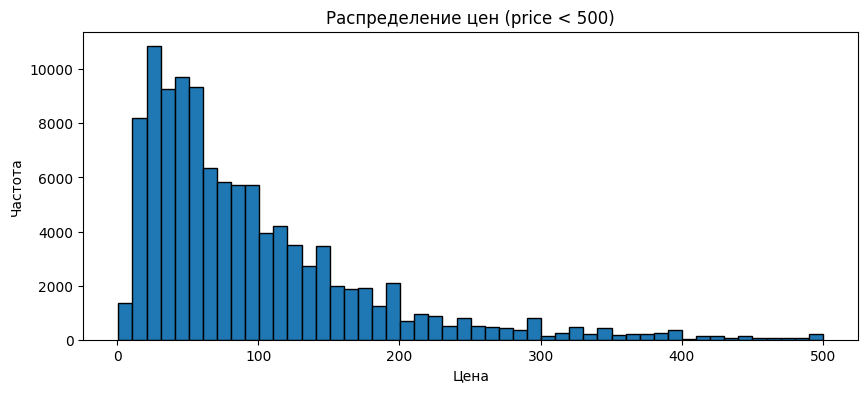

In [14]:
print("Статистика price в order_items:")
print(order_items['price'].describe())

zero_price = order_items[order_items['price'] == 0]
print(f"\nКоличество товаров с price = 0: {len(zero_price)}")

high_price = order_items[order_items['price'] > 1000]
print(f"Количество товаров с price > 1000: {len(high_price)}")

price_filtered = order_items[order_items['price'] < 500]['price']
plt.figure(figsize=(10,4))
plt.hist(price_filtered, bins=50, edgecolor='black')
plt.title('Распределение цен (price < 500)')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

## 1.4 Обработка выбросов и пропусков

**Принятые решения:**
- Пропуски в `order_delivered_customer_date` оставляем — это заказы, которые не были доставлены.
- Цена = 0 исключаем из расчёта LTV и среднего чека (вероятно, технический баг или тестовые заказы).
- Цены > 1000 оставляем — это дорогие товары (электроника, мебель), они реальны.

In [15]:
order_items_clean = order_items[order_items['price'] > 0].copy()
print(f"Удалено записей с price=0: {len(order_items) - len(order_items_clean)}")

order_value_clean = order_items_clean.groupby('order_id')['price'].sum().reset_index()

Удалено записей с price=0: 0


# 4. Анализ пользователей

## Распределение пользователей по количеству заказов

Наблюдается сильный перекос:
- большинство пользователей делает **только 1 заказ**
- доля пользователей с повторными покупками значительно ниже

---

## Интерпретация

Это первый сигнал возможной проблемы:

пользователи не возвращаются после первой покупки

---

## Промежуточный вывод

Платформа может испытывать проблемы с удержанием пользователей.

Далее проверим это через явный анализ retention.

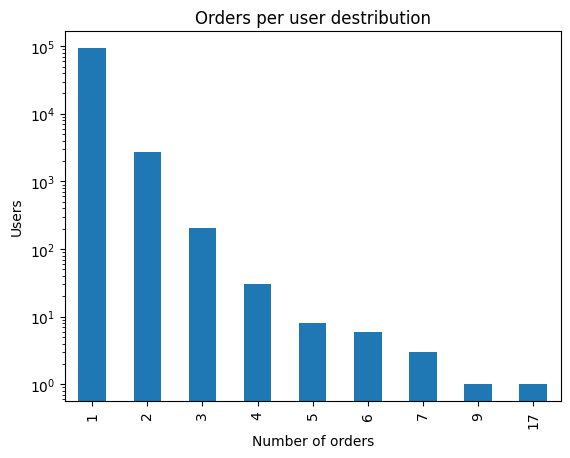

In [27]:
orders_per_user = df.groupby('customer_unique_id')['order_id'].nunique()

plt.figure()

orders_per_user.value_counts().sort_index().plot( kind = 'bar' )

plt.yscale( 'log' )

plt.title( 'Orders per user destribution' )
plt.xlabel( 'Number of orders' )
plt.ylabel( 'Users' )
plt.show()

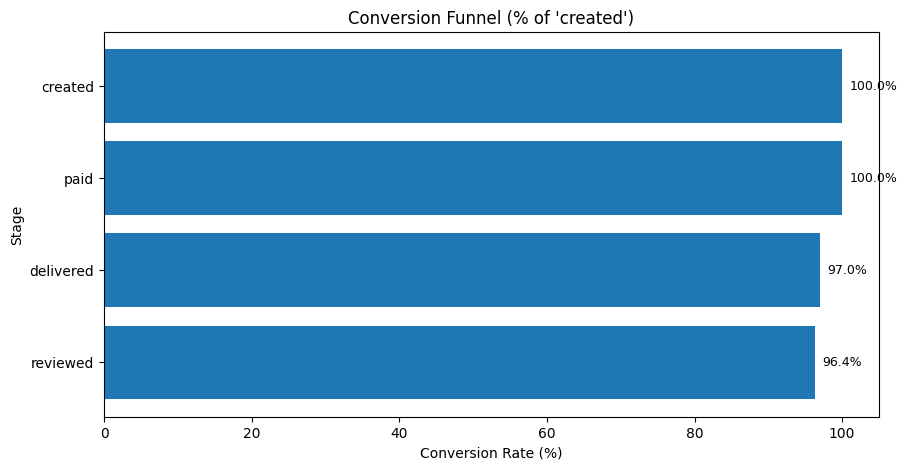

In [31]:
funnel = {
    'created': orders['order_id'].nunique(),
    'paid': payments['order_id'].nunique(),
    'delivered': orders[orders['order_status'] == 'delivered']['order_id'].nunique(),
    'reviewed': reviews[reviews['order_id'].isin(orders[orders['order_status'] == 'delivered']['order_id'])]['order_id'].nunique()
}

first_value = list(funnel.values())[0]
steps = list(funnel.keys())
percentages_from_first = [(v / first_value) * 100 for v in funnel.values()]

plt.figure(figsize=(10,5))
plt.barh(steps, percentages_from_first)
plt.gca().invert_yaxis()

plt.title("Conversion Funnel (% of 'created')")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Stage")

for i, (step, pct) in enumerate(zip(steps, percentages_from_first)):
    plt.text(pct + 1, i, f'{pct:.1f}%', va='center', fontsize=9)

plt.show()

In [29]:
seller_rev = order_items.groupby('seller_id')['price'].sum().sort_values(ascending = False)

total_revenue = seller_rev.sum()
perc_top_10 = seller_rev.head(10).sum() / total_revenue

print("% of Revenue bu Top 10 sellers:", perc_top_10.round(2) * 100, "%")

% of Revenue bu Top 10 sellers: 13.0 %


# 5. Проблема: низкий retention

На предыдущем шаге мы увидели, что большинство пользователей делает только один заказ.

Это указывает на потенциально низкий retention.

## Почему это важно?

- удержание дешевле привлечения
- повторные покупки формируют основную выручку
- retention влияет на LTV

---

## Гипотеза

Пользователи не возвращаются после первой покупки → низкий retention является ключевой проблемой продукта.

Далее количественно оценим retention.

In [20]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

order_value = order_items.groupby( 'order_id' )[ 'price' ].sum().reset_index()

df = orders.merge( order_value, on = 'order_id', how = 'left' )
df = df.merge( customers, on = 'customer_id', how = 'left' )

In [21]:
df[ 'order_date' ] = pd.to_datetime( df[ 'order_purchase_timestamp' ] )
df[ 'order_month' ] = df[ 'order_date' ].dt.to_period( 'M' )

df[ 'cohort' ] = df.groupby( 'customer_unique_id' )[ 'order_month' ].transform( 'min' )
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_date,order_month,cohort
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10-02 10:56:33,2017-10,2017-09
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07-24 20:41:37,2018-07,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08-08 08:38:49,2018-08,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11-18 19:28:06,2017-11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02-13 21:18:39,2018-02,2018-02


In [22]:
cohort_data = df.groupby( [ 'cohort', 'order_month' ] )[ 'customer_unique_id' ].nunique().reset_index()

cohort_data[ 'period_number' ] = ( cohort_data[ 'order_month' ] - cohort_data[ 'cohort' ] ).apply( lambda x: x.n )
cohort_data.head()

,cohort,order_month,customer_unique_id,period_number
0,2016-09,2016-09,4,0
1,2016-10,2016-10,321,0
2,2016-10,2017-04,1,6
3,2016-10,2017-07,1,9
4,2016-10,2017-09,1,11


In [23]:
cohort_pivot = cohort_data.pivot(
    index = 'cohort',
    columns = 'period_number',
    values = 'customer_unique_id'
)
cohort_pivot.head()

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


In [24]:
retention = cohort_pivot.divide( cohort_pivot[0], axis = 0 )
retention = retention.fillna(0)
retention.head()

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-10,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.003115,0.000000,0.000000,0.003115,0.000000,0.003115,0.000000,0.003115,0.000000,0.003115,0.000000,0.003115,0.006231,0.006231
2016-12,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-01,1.0,0.003927,0.002618,0.001309,0.003927,0.001309,0.005236,0.001309,0.001309,0.000000,0.003927,0.001309,0.007853,0.003927,0.001309,0.001309,0.002618,0.003927,0.001309,0.000000
2017-02,1.0,0.002283,0.002854,0.001142,0.003995,0.001142,0.002283,0.001712,0.001712,0.002283,0.001142,0.002854,0.001712,0.001712,0.001142,0.000571,0.000571,0.002283,0.000000,0.000000


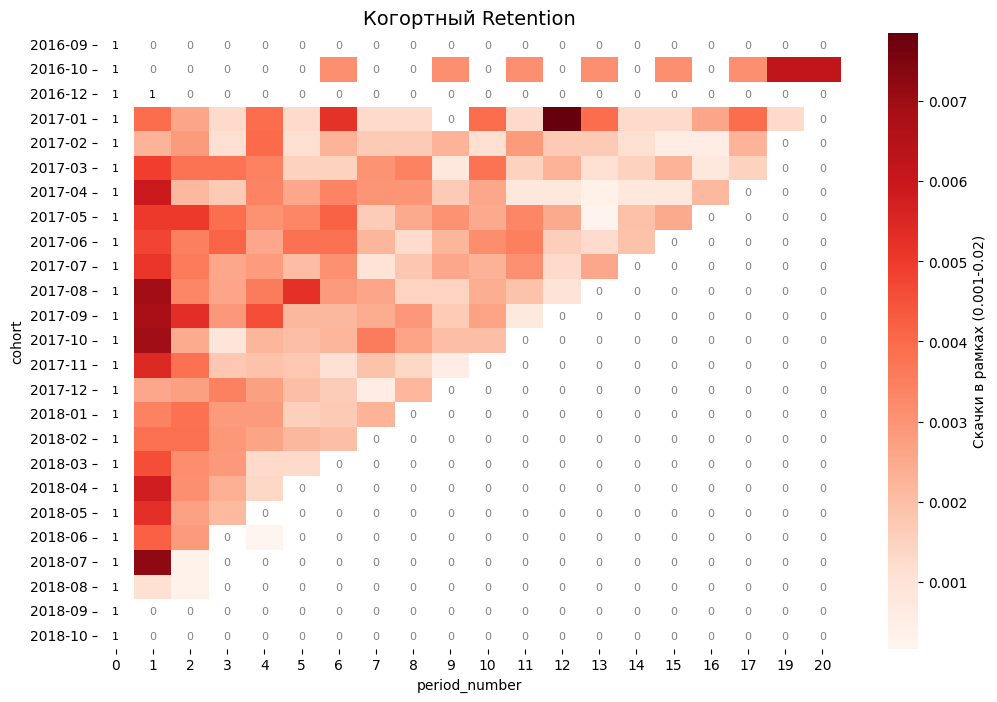

In [25]:
plt.figure(figsize=(12, 8))

fluctuations = retention.where((retention > 0) & (retention < 0.02), np.nan)

ax = sns.heatmap(
    fluctuations,
    annot=False,
    cmap='Reds',
    cbar_kws={'label': 'Скачки в рамках (0.001-0.02)'}
)

for i in range(len(retention)):
    for j in range(len(retention.columns)):
        val = retention.iloc[i, j]
        if val == 0:
            ax.text(j+0.5, i+0.5, '0', ha='center', va='center', color='gray', fontsize=8)
        elif val == 1:
            ax.text(j+0.5, i+0.5, '1', ha='center', va='center', color='black', fontsize=8)

plt.title('Когортный Retention', fontsize=14)
plt.show()

# 6. Анализ retention

Рассчитаем долю пользователей, совершивших более одного заказа.

## Наблюдение

- доля пользователей с повторными покупками низкая  
- большинство пользователей не возвращается  

---

## Интерпретация

платформа не формирует долгосрочную ценность для пользователя  

Пользовательский сценарий:
1. пользователь приходит  
2. совершает покупку  
3. покидает платформу  

---

## Вывод

Retention действительно низкий и является ключевой проблемой.

# 7. Повторные покупки

Рассмотрим более подробно поведение пользователей, совершающих повторные заказы.

In [28]:
repeat_rate = (orders_per_user > 1).mean()

print(f"Доля пользователей с > 1 покупки: {repeat_rate:.2%}")

Доля пользователей с > 1 покупки: 3.12%


## Наблюдение

- небольшая доля пользователей возвращается  
- повторные покупки происходят редко  

---

## Интерпретация

у пользователей не формируется привычка пользоваться платформой  

---

## Вывод

Retention слабый не только в моменте, но и в долгосрочном поведении пользователей.

# 8. Анализ выручки

Рассмотрим распределение выручки и вклад пользователей.

   num_orders  clients  total_revenue  avg_revenue_per_client
0           1    93099    15064849.41              161.815373
1           2     2745      809355.39              294.847137
2           3      203       96097.83              473.388325
3           4       30       23373.88              779.129333
4           5        8        6077.25              759.656250
5           6        6        4177.51              696.251667
6           7        3        2840.56              946.853333
7           9        1        1172.66             1172.660000
8          17        1         927.63              927.630000


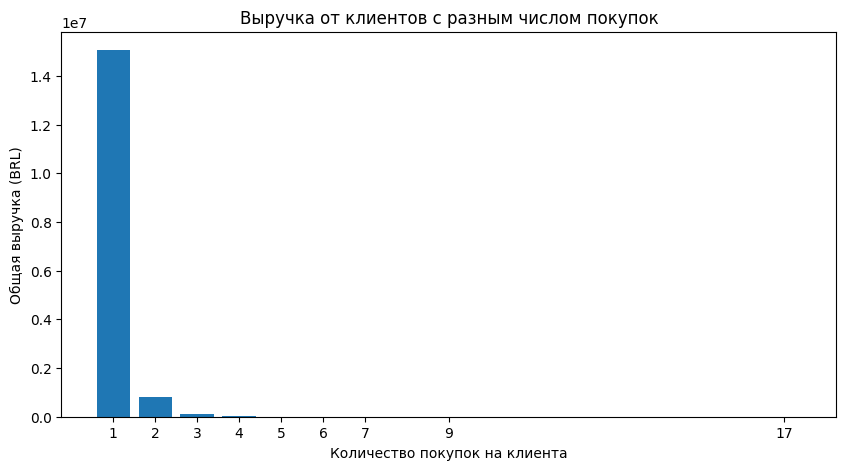

In [33]:
order_revenue = payments.groupby('order_id')['payment_value'].sum().reset_index()
order_revenue.columns = ['order_id', 'order_total']

customer_orders = df[['customer_unique_id', 'order_id']].drop_duplicates()
customer_orders = customer_orders.merge(order_revenue, on='order_id', how='left')

customer_stats = customer_orders.groupby('customer_unique_id').agg(
    num_orders=('order_id', 'nunique'),
    total_revenue=('order_total', 'sum')
).reset_index()

revenue_by_orders = customer_stats.groupby('num_orders').agg(
    clients=('customer_unique_id', 'count'),
    total_revenue=('total_revenue', 'sum'),
    avg_revenue_per_client=('total_revenue', 'mean')
).reset_index()

print(revenue_by_orders)

plt.figure(figsize=(10,5))
plt.bar(revenue_by_orders['num_orders'], revenue_by_orders['total_revenue'])
plt.xlabel('Количество покупок на клиента')
plt.ylabel('Общая выручка (BRL)')
plt.title('Выручка от клиентов с разным числом покупок')
plt.xticks(revenue_by_orders['num_orders'])
plt.show()

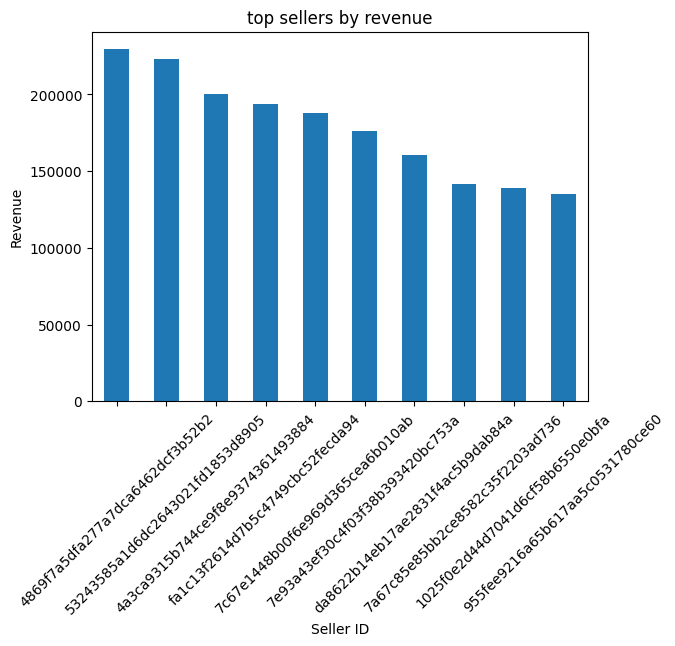

In [32]:
top_sellers = seller_rev.head(10)

top_sellers.plot(kind = 'bar')

plt.title("top sellers by revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")

plt.xticks(rotation = 45)
plt.show()

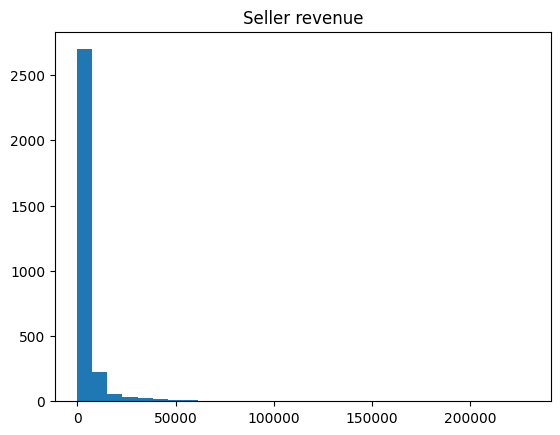

In [41]:
plt.hist(seller_rev, bins = 30)

plt.title("Seller revenue")
plt.show()

## Наблюдения

- основная часть выручки формируется за счет **первой покупки**
- вклад повторных заказов относительно небольшой  
- нет значительной доли "тяжелых" пользователей (heavy users)

---

## Интерпретация

    выручка зависит от постоянного притока новых пользователей  

Это означает:
- бизнес масштабируется за счет привлечения  
- а не за счет удержания  

---

## Риск

Такая модель нестабильна:
- высокая зависимость от маркетинга  
- рост затрат на привлечение (CAC)  
- слабая база постоянных клиентов  

---

## Вывод

Текущая структура выручки подтверждает проблему низкого retention:

    пользователи не генерируют долгосрочную ценность

# 9. Анализ LTV (Lifetime Value)

Оценим LTV пользователя через количество заказов и средний чек.

In [37]:
df['delivery_time'] = ( df['order_delivered_customer_date'] - df['order_purchase_timestamp'] ).dt.days
ltv_df = df.groupby( 'customer_unique_id' )[ 'price' ].sum().reset_index()

avg_ltv = ltv_df[ 'price' ].mean()

print('Average LTV:', avg_ltv)

Average LTV: 141.4381836913087


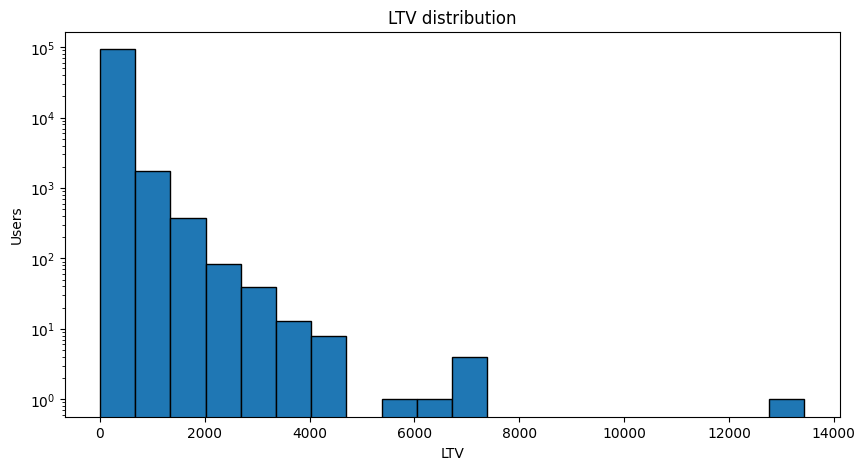

In [38]:
plt.figure(figsize=(10,5))

plt.hist( ltv_df[ 'price' ], bins = 20, edgecolor = 'black' )

plt.yscale( 'log' )

plt.title( 'LTV distribution' )
plt.xlabel( 'LTV' )
plt.ylabel( 'Users' )
plt.show()

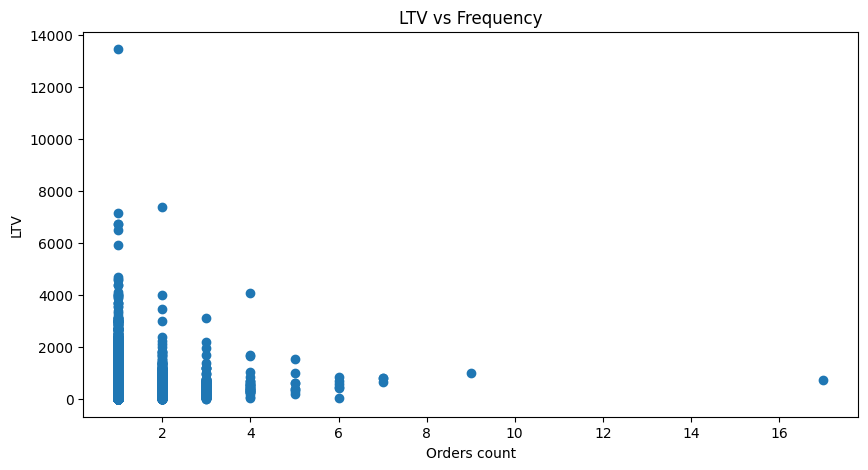

In [39]:
rfm = df.groupby( 'customer_unique_id' ).agg( {'order_id': 'nunique', 'price': 'sum'}).reset_index()

rfm.columns = [ 'customer_id', 'frequency', 'ltv' ]

plt.figure(figsize=(10,5))
plt.scatter( rfm[ 'frequency' ], rfm[ 'ltv'] )
plt.title( 'LTV vs Frequency' )
plt.xlabel( 'Orders count' )
plt.ylabel( 'LTV' )
plt.show()

## Наблюдения

- большинство пользователей имеют **минимальный LTV**
- LTV ограничен одной покупкой  
- очень мало пользователей с высоким накопленным вкладом  

---

## Интерпретация

    пользователь не "раскрывается" во времени  

В нормальной ситуации:
- пользователь делает повторные покупки  
- его LTV растет  

Здесь:
- LTV остается на уровне первой транзакции  

---

## Вывод

Низкий retention напрямую приводит к низкому LTV.

    платформа не извлекает долгосрочную ценность из пользователей

# 10. Связь retention, revenue и LTV

Объединим ключевые метрики:

- Retention — низкий  
- Повторные покупки — редкие  
- LTV — низкий  
- Revenue — зависит от новых пользователей  

---

## Главный инсайт

    !!!Все метрики связаны одной проблемой — отсутствием удержания!!!

---

## Причинно-следственная связь

Низкий retention -  
мало повторных покупок -  
низкий LTV -  
зависимость от привлечения -  
рост затрат  

---

## Бизнес-вывод

    текущая модель роста неустойчива  

Без улучшения retention:
- невозможно масштабировать прибыль  
- каждый новый пользователь "одноразовый"  

# 11. Поиск причин низкого retention

Мы выявили проблему: пользователи не возвращаются.

Теперь важно понять **почему это происходит**.

Рассмотрим возможные факторы:
- категории товаров  
- качество товаров (оценки)  
- пользовательский опыт  

Начнем с анализа категорий.

In [35]:
orders_per_user = df.groupby( 'customer_unique_id' )[ 'order_id' ].nunique()

repeat_rate = ( orders_per_user > 1 ).mean()

print( 'Частота возврата клиента:', repeat_rate )

Частота возврата клиента: 0.031187562437562436


# 12. Анализ категорий товаров

Рассмотрим наиболее популярные категории по количеству заказов.

## Наблюдение

- выделяется ряд категорий с высокой популярностью  
- пользователи активно совершают покупки в этих категориях  

---

## Интерпретация

    категории успешно привлекают пользователей  

Однако важно:

    высокая популярность не означает высокий retention  

---

Далее проверим, удерживают ли эти категории пользователей.

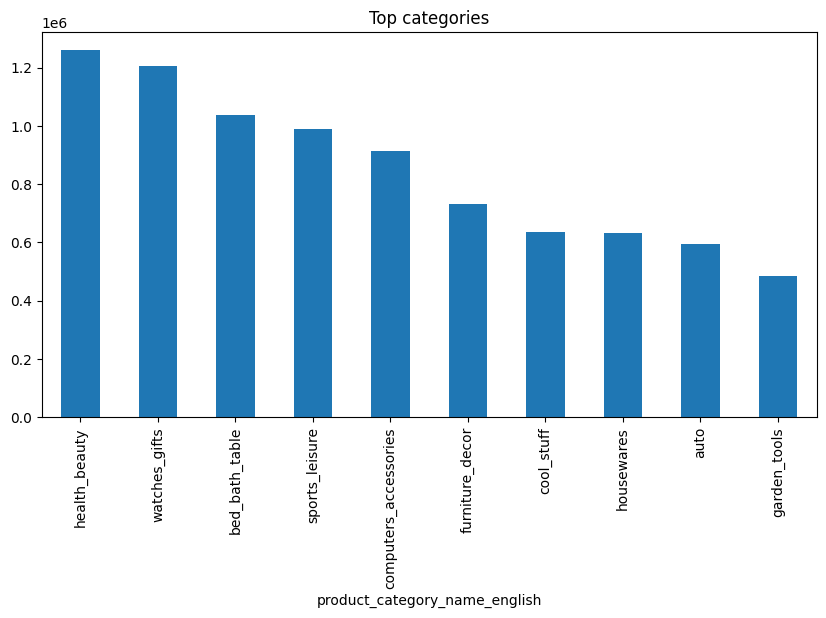

In [41]:
category = order_items.merge( products, on = 'product_id', how = 'left' )
category = category.merge(category_translation, on = 'product_category_name', how = 'left' )

top_categories = category.groupby( 'product_category_name_english' )[ 'price' ].sum().sort_values( ascending = False ).head(10)

plt.figure(figsize=(10,5))
top_categories.plot( kind ='bar' )
plt.title( 'Top categories' )
plt.show()

In [78]:
first_items = order_items.merge(first_orders[['order_id', 'is_repeat']], on='order_id')
first_items = first_items.merge(products[['product_id', 'product_category_name']], on='product_id')
first_items = first_items.merge(category_translation, on='product_category_name')

repeat_cats = first_items[first_items['is_repeat']]['product_category_name_english'].value_counts().head(5)
print("Категории у повторных клиентов:\n", repeat_cats)

non_repeat_cats = first_items[~first_items['is_repeat']]['product_category_name_english'].value_counts().head(10)
print("\nКатегории у неповторных клиентов:\n", non_repeat_cats)

Категории у повторных клиентов:
 product_category_name_english
bed_bath_table           498
furniture_decor          400
sports_leisure           309
health_beauty            248
computers_accessories    236
Name: count, dtype: int64

Категории у неповторных клиентов:
 product_category_name_english
bed_bath_table           9880
health_beauty            8936
sports_leisure           7791
furniture_decor          7362
computers_accessories    7116
housewares               6382
watches_gifts            5547
telephony                4207
garden_tools             4027
auto                     3961
Name: count, dtype: int64


# 13. Аномалия: категория health_beauty

Категория *health_beauty*:
- входит в число популярных по количеству заказов  
- но не демонстрирует высокий retention  

---

## Почему это важно?

Товары этой категории:
- являются расходуемыми  
- предполагают регулярные покупки  

    Ожидание: высокий retention  
    Факт: пользователи не возвращаются  

In [77]:
reviews_cat = reviews.merge(order_items[['order_id', 'product_id']], on='order_id')
reviews_cat = reviews_cat.merge(products[['product_id', 'product_category_name']], on='product_id')
reviews_cat = reviews_cat.merge(category_translation, on='product_category_name')

cat_scores = reviews_cat.groupby('product_category_name_english').agg(
    review_score_mean=('review_score', 'mean'),
    review_count=('review_id', 'count')
).reset_index()
cat_scores = cat_scores[cat_scores['review_count'] > 100].sort_values('review_score_mean')

print("Худшие категории по оценкам:")
print(cat_scores.head(10).to_string(index=False))

print("\nЛучшие категории по оценкам:")
print(cat_scores.sort_values('review_score_mean', ascending=False).head(20).to_string(index=False))

# Оценки по health_beauty
hb_scores = reviews_cat[reviews_cat['product_category_name_english'] == 'health_beauty']['review_score']
print(f"\nhealth_beauty: средняя оценка = {hb_scores.mean():.2f}, медиана = {hb_scores.median()}, количество отзывов = {len(hb_scores)}")

Худшие категории по оценкам:
product_category_name_english  review_score_mean  review_count
             office_furniture           3.493183          1687
        fashion_male_clothing           3.641221           131
              fixed_telephony           3.683206           262
                        audio           3.825485           361
                 home_confort           3.829885           435
    construction_tools_safety           3.844560           193
               bed_bath_table           3.895663         11137
              furniture_decor           3.903493          8331
        furniture_living_room           3.904382           502
        computers_accessories           3.930819          7849

Лучшие категории по оценкам:
product_category_name_english  review_score_mean  review_count
       books_general_interest           4.446266           549
              books_technical           4.368421           266
                   food_drink           4.315412           

Сравнение цен в health_beauty для повторных и неповторных клиентов:
            count        mean         std  min     25%   50%      75%      max
is_repeat                                                                     
False      9103.0  132.018381  182.000693  1.2  40.825  79.9  131.995  3124.00
True        567.0  100.384515  129.579119  6.0  34.990  69.9  110.320  1375.65


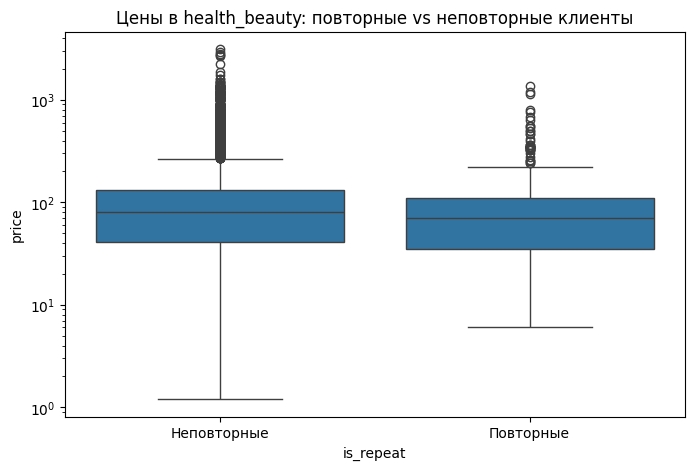

In [68]:
# 2. Сравним среднюю цену в health_beauty для повторных и неповторных клиентов
hb_items['customer_id'] = hb_items['order_id'].map(df.set_index('order_id')['customer_unique_id'])
hb_items['is_repeat'] = hb_items['customer_id'].isin(repeat_customers)

price_comp = hb_items.groupby('is_repeat')['price'].describe()
print("Сравнение цен в health_beauty для повторных и неповторных клиентов:")
print(price_comp)

plt.figure(figsize=(8,5))
sns.boxplot(data=hb_items, x='is_repeat', y='price')
plt.title('Цены в health_beauty: повторные vs неповторные клиенты')
plt.xticks([0,1], ['Неповторные', 'Повторные'])
plt.yscale('log')
plt.show()

## Дополнительное наблюдение

Категория имеет **средние оценки (топ-18)**

---

## Возможные причины

1. Среднее качество товаров — пользователи не удовлетворены  

2. Отсутствие привязки к бренду — покупка разовая  

3. Высокая конкуренция — легко уйти на другую платформу  

4. Нет механик возврата — пользователь не получает стимул вернуться  

---

## Вывод

Даже в категориях с естественным потенциалом повторных покупок retention остается низким.

    проблема глубже, чем просто выбор категории

# 14. Анализ оценок товаров

Рассмотрим распределение пользовательских оценок.

<Axes: xlabel='review_score', ylabel='delivery_time'>

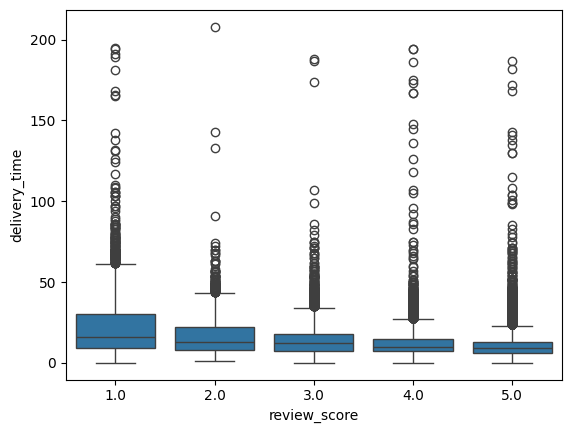

In [79]:
review_df = df.merge( reviews, on = 'order_id', how = 'left' )

sns.boxplot( x = 'review_score', y = 'delivery_time', data = review_df )

## Наблюдение

- оценки в среднем находятся на среднем уровне  
- нет явного преобладания высоких оценок  

---

## Интерпретация

пользовательский опыт нельзя назвать выдающимся  

Пользователь:
- получает товар  
- но не испытывает сильного положительного эффекта  

---

## Вывод

Отсутствие высокого качества опыта может быть причиной низкого retention.

# 15. Связь оценок и возврата пользователей

## Гипотеза

Пользователи с более высоким уровнем удовлетворенности должны чаще возвращаться.

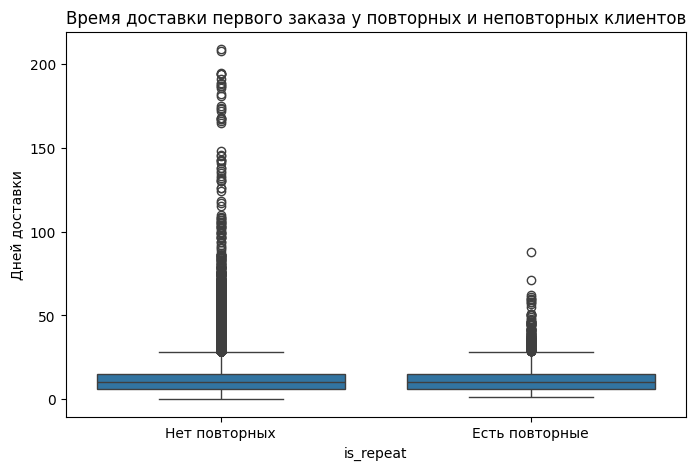

In [62]:
delivered_orders = df[df['order_status'] == 'delivered'].copy()
delivered_orders['delivery_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.days

first_orders = delivered_orders.sort_values('order_purchase_timestamp').groupby('customer_unique_id').first().reset_index()
repeat_orders = delivered_orders[delivered_orders.duplicated('customer_unique_id', keep='first')]

repeat_customers = repeat_orders['customer_unique_id'].unique()
first_orders['is_repeat'] = first_orders['customer_unique_id'].isin(repeat_customers)

plt.figure(figsize=(8,5))
sns.boxplot(x='is_repeat', y='delivery_days', data=first_orders)
plt.title('Время доставки первого заказа у повторных и неповторных клиентов')
plt.xticks([0,1], ['Нет повторных', 'Есть повторные'])
plt.ylabel('Дней доставки')
plt.show()

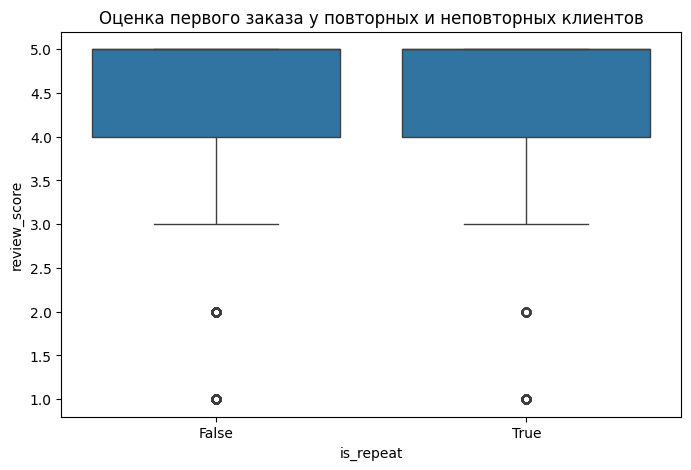

In [63]:
# Средняя оценка первого заказа для повторных и неповторных
reviews_first = reviews.merge(first_orders[['order_id', 'is_repeat']], on='order_id')
plt.figure(figsize=(8,5))
sns.boxplot(x='is_repeat', y='review_score', data=reviews_first)
plt.title('Оценка первого заказа у повторных и неповторных клиентов')
plt.show()

In [65]:
status_counts = orders['order_status'].value_counts()
print(status_counts)

cancelled = orders[orders['order_status'] == 'canceled']
print(f"Доля отмен: {len(cancelled)/len(orders):.2%}")

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
Доля отмен: 0.63%


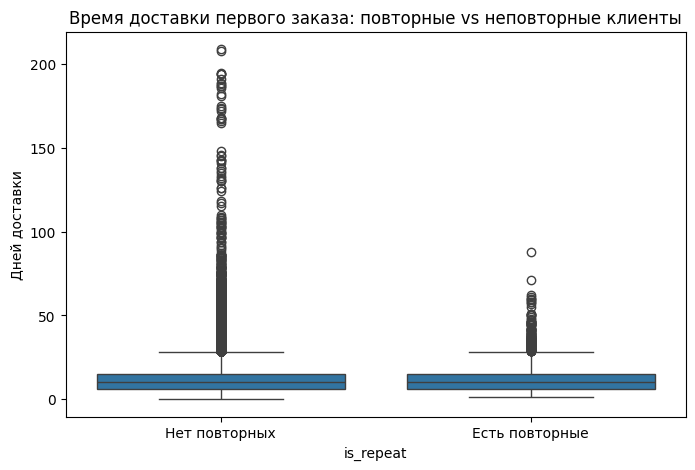

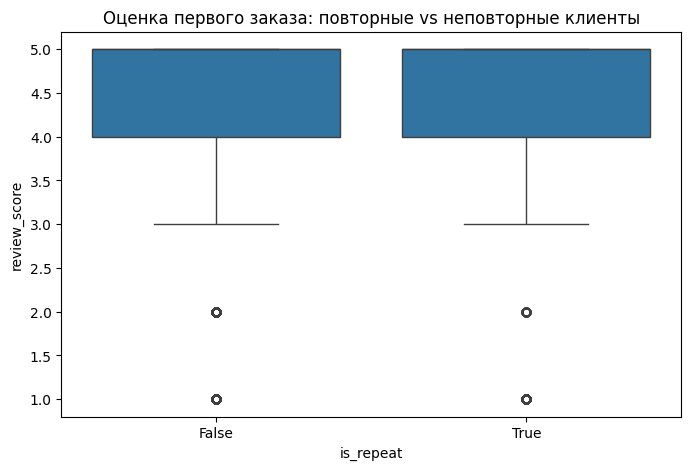

In [70]:
# Сравнение времени доставки первого заказа
first_orders['delivery_days'] = (first_orders['order_delivered_customer_date'] - 
                                 first_orders['order_purchase_timestamp']).dt.days

plt.figure(figsize=(8,5))
sns.boxplot(x='is_repeat', y='delivery_days', data=first_orders)
plt.title('Время доставки первого заказа: повторные vs неповторные клиенты')
plt.xticks([0,1], ['Нет повторных', 'Есть повторные'])
plt.ylabel('Дней доставки')
plt.show()

# Оценки первого заказа
reviews_first = reviews.merge(first_orders[['order_id', 'is_repeat']], on='order_id')
plt.figure(figsize=(8,5))
sns.boxplot(x='is_repeat', y='review_score', data=reviews_first)
plt.title('Оценка первого заказа: повторные vs неповторные клиенты')
plt.show()

## Наблюдение

- даже при средних оценках пользователи не возвращаются  
- высокая оценка не гарантирует повторную покупку  

---

## Интерпретация

    средний опыт недостаточен для удержания  

Чтобы пользователь вернулся, необходимо:
- либо очень высокое качество  
- либо дополнительные стимулы  

---

## Вывод

Оценки влияют на retention, но не являются ключевым фактором.

# Итоговый вывод по проекту

В ходе анализа было изучено поведение пользователей, структура заказов, категории товаров, оценки, а также ключевые бизнес-метрики — retention, revenue и LTV.

---

## Ключевые наблюдения

1. Большинство пользователей совершает только одну покупку  
— платформа имеет **низкий retention**

2. Повторные покупки происходят редко  
— не формируется пользовательская привычка

3. Выручка в основном формируется за счет новых пользователей  
— высокая зависимость от привлечения

4. LTV пользователей низкий  
— пользователь не приносит долгосрочную ценность

5. Популярные категории не удерживают пользователей  
— спрос есть, но он не конвертируется в лояльность

6. Даже категории с естественным потенциалом повторных покупок (например, *health_beauty*) не демонстрируют высокий retention  

7. Оценки товаров находятся на среднем уровне  
— пользовательский опыт не является достаточно сильным для возврата

---

## Главный инсайт

    !!!Основная проблема — не привлечение пользователей, а их удержание!!!

Платформа эффективно приводит пользователей к первой покупке,  
но не создает условий для их возврата.

---

## Причинно-следственная модель

Низкий retention —  
мало повторных покупок —  
низкий LTV —  
зависимость от привлечения —  
рост затрат и ограничение роста бизнеса  

---

## Бизнес-интерпретация

На текущий момент продукт функционирует как:

    сервис разовых покупок, а не как платформа с постоянной клиентской базой  

Это делает бизнес-модель:
- менее устойчивой  
- зависимой от маркетинга  
- ограниченной в масштабировании  

---

## Ключевая точка роста

    Увеличение retention является главным драйвером роста

Рост удержания приведет к:
- увеличению LTV  
- снижению CAC  
- росту выручки без пропорционального роста затрат  

---

## Общий вывод

Для устойчивого развития продукту необходимо сместить фокус:
    с привлечения пользователей  
    на формирование долгосрочной ценности и лояльности  

---

## Финальный вывод

Retention — это центральная проблема и одновременно главный рычаг роста продукта.